In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
x_left = [-1.633,-1.53,-1.415,-1.294,-1.156,-1,-0.817,-0.6,0]
x_right = []
for i in range(len(x_left)-2, -1, -1):
  x_right.append(-1*x_left[i])

x_vals = x_left + x_right

y_left = [10,9.0227,8.00668,7.02331,6.00901,5,4.00247,3.08,2]
y_right = []
for j in range(len(y_left)-2, -1, -1):
  y_right.append(y_left[j])

y_vals = y_left + y_right

In [ ]:
def w_single_loss(y1, w1, x1, b1):
  result = 2*(y1-(w1*(x1**2))-b1)*(x1**2)
  return result

def b_single_loss(y1, w1, x1, b1):
  result = 2*(y1-(w1*(x1**2))-b1)
  return result

def avg_loss(b, w, x_vals, y_vals):
  loss_sum_w = 0
  loss_sum_b = 0
  for k in range(0, len(x_vals), 1):
    x, y = x_vals[k], y_vals[k]
    loss_sum_w += w_single_loss(y, w, x, b)
    loss_sum_b += b_single_loss(y, w, x, b)

  avg_loss_w = loss_sum_w / len(x_vals)
  avg_loss_b = loss_sum_b / len(x_vals)

  return (avg_loss_w, avg_loss_b)

def update_params(a, b, w, x_vals, y_vals):
  avg_loss_w, avg_loss_b = avg_loss(b, w, x_vals, y_vals)
  w_new = w + a * avg_loss_w
  b_new = b + a * avg_loss_b

  return (w_new, b_new)

def get_new_y(a, b, w, x_vals, y_vals):
  w_new, b_new = update_params(a, b, w, x_vals, y_vals)
  new_ys = []

  for p in range(0, len(x_vals), 1):
    x = x_vals[p]
    y_new = w_new * (x**2) + b_new
    new_ys.append(y_new)

  return (w_new, b_new, new_ys)

In [38]:
w1 = 3.75
b1 = 1.25
a = 0.1
y_nested = []
w_error = []
b_error = []

for m in range(0, 50, 1):
  w_new, b_new, y_li = get_new_y(a, b1, w1, x_vals, y_vals)

  y_nested.append(y_li)

  w_error.append(abs(3-w_new))
  b_error.append(abs(2-b_new))

  w1 = w_new
  b1 = b_new
  # print(f"w1={w1}, b1={b1}")

# print(y_nested)



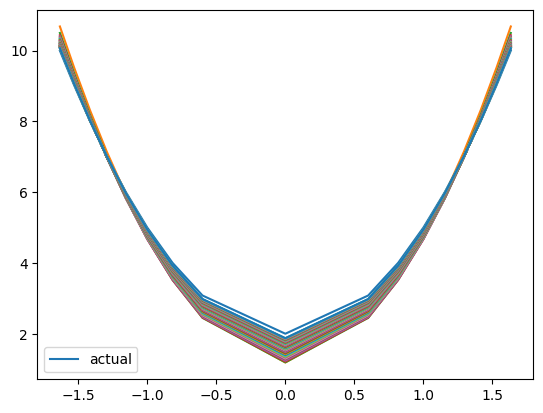

In [39]:
plt.plot(x_vals, y_vals, label=f"actual")
for n in range(0, len(y_nested), 1):
  plt.plot(x_vals, y_nested[n])
plt.legend()
plt.show()


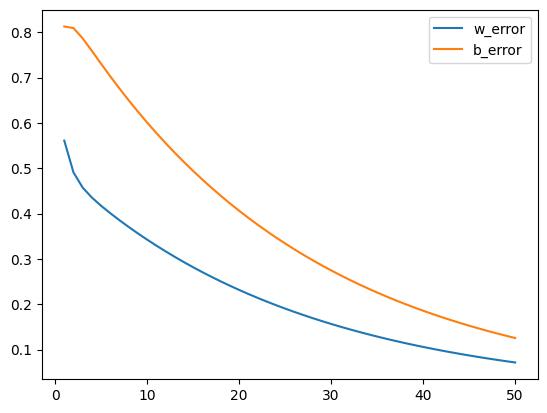

In [40]:
points = len(w_error)
t = np.linspace(1, points, points)
plt.plot(t, w_error, label="w_error")
plt.plot(t, b_error, label="b_error")
plt.legend()
plt.show()